# LangGraph를 이용한 Supervisor Agents RAG

## 1. Supervisor Agents RAG 개요

Supervisor Agents RAG는 **여러 전문 에이전트들을 관리하는 Supervisor 패턴**을 적용한 고급 RAG 시스템입니다.

### 1.1 Supervisor 패턴이란?

- **Supervisor**: 전체 워크플로우를 관리하고 어떤 에이전트를 사용할지 결정하는 중앙 관리자
- **Agents**: 각각의 전문 작업을 수행하는 독립적인 에이전트들
  - VectorSearchAgent: 벡터 데이터베이스 검색
  - WebSearchAgent: 웹 검색
  - EvaluationAgent: 문서 관련성 평가
  - AnswerGenerator: 답변 생성
  - QualityChecker: 답변 품질 검증

### 1.2 기존 RAG와의 차이점

| 구분 | Vanilla RAG | Corrective RAG | Self-RAG | Supervisor Agents RAG |
|------|-------------|----------------|----------|----------------------|
| **구조** | 단순 파이프라인 | 조건부 분기 | 자체 평가 | 다중 에이전트 협업 |
| **검색** | 항상 벡터 검색 | 벡터 → 평가 → 웹 | 필요시만 검색 | Supervisor가 선택 |
| **평가** | 없음 | 검색 품질 평가 | 관련성/지지도 평가 | 전용 평가 에이전트 |
| **품질 관리** | 없음 | 검색 교정 | 답변 검증 | 전용 품질 검증 에이전트 |

## 2. 환경 설정


### API 키 설정
- [OpenAI API 키](https://platform.openai.com/api-keys)
- [Tavily API 키](https://tavily.com/) - 웹 검색용


In [1]:
import warnings
warnings.filterwarnings("ignore")


In [2]:
from dotenv import load_dotenv

load_dotenv()


True

In [3]:
import os 

# API 키 확인
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key:
    print("OpenAI API 키가 설정되었습니다. (GPT 모델 사용)")
else:
    print("OpenAI API 키가 없습니다.")

if tavily_key:
    print("Tavily API 키가 설정되었습니다. (웹 검색 사용)")
else:
    print("Tavily API 키가 설정되지 않았습니다. 웹 검색 기능이 제한될 수 있습니다.")
    print("   https://tavily.com/ 에서 무료 API 키를 받아 설정해주세요.")


OpenAI API 키가 설정되었습니다. (GPT 모델 사용)
Tavily API 키가 설정되었습니다. (웹 검색 사용)


## 3. LangGraph State 정의

Supervisor Agents RAG 시스템의 상태를 관리하기 위한 State 클래스를 정의합니다.


In [4]:
from typing import List, Dict, Any, Optional
from typing_extensions import TypedDict
from langchain_core.documents import Document

class SupervisorRAGState(TypedDict):
    """Supervisor Agents RAG 시스템의 상태를 정의하는 클래스"""
    
    # 입력 정보
    question: str  # 사용자 질문
    
    # Supervisor 결정
    selected_agent: str  # 선택된 에이전트 ("vector", "web", "both")
    need_web_search: bool  # 웹 검색 필요 여부
    
    # 검색 관련
    vector_docs: List[Document]  # 벡터 검색 결과
    web_docs: List[Document]  # 웹 검색 결과
    all_docs: List[Document]  # 모든 검색 결과
    
    # 평가 관련 (Vanilla RAG의 evaluate_relevance_with_llm 적용)
    relevant_docs: List[Document]  # 관련성이 있는 문서들
    sources: List[str]  # 출처 정보
    
    # 답변 생성 관련
    answer: str  # 생성된 답변
    
    # 품질 검증 관련 (Self-RAG 스타일)
    quality_score: float  # 품질 점수
    confidence: str  # 신뢰도 ("high", "medium", "low")
    
    # 최종 결과
    final_answer: str  # 최종 답변 (출처 포함)
    generation_strategy: str  # 사용된 전략 설명

print("SupervisorRAGState 클래스 정의 완료!")


SupervisorRAGState 클래스 정의 완료!


## 4. Vector DB

### Embedding Model


In [5]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")


### Elasticsearch Client

In [6]:
from elasticsearch import Elasticsearch
import warnings

# SSL 경고 무시 (개발 환경용)
warnings.filterwarnings('ignore')

# Elasticsearch 클라이언트 생성
# elasticsearch 9.x는 명시적인 scheme 지정이 필요합니다
try:
    es_client = Elasticsearch(
        ["http://localhost:9200"],  # 리스트 형태로, scheme 포함
        basic_auth=("elastic", "changeme123!"),  # 인증 정보 (보안 활성화 시 필수)
        verify_certs=False,
        ssl_show_warn=False,
        request_timeout=30,
        max_retries=3,
        retry_on_timeout=True,
        # 호환성 헤더 비활성화 (개발 환경용)
        headers={"accept": "application/json", "content-type": "application/json"}
    )
    
    # 연결 확인
    if es_client.ping():
        print("Elasticsearch 연결 성공!")
        print()
        
        # 클러스터 정보
        info = es_client.info()
        print(f"버전: {info['version']['number']}")
        print(f"클러스터 이름: {info['cluster_name']}")
        print(f"노드 이름: {info['name']}")
        print()
        print(f"Elasticsearch URL: http://localhost:9200")
    else:
        print("Elasticsearch 연결 실패 (ping 실패)")
        
except Exception as e:
    print("Elasticsearch 연결 중 오류 발생:")
    print(f"   에러 타입: {type(e).__name__}")
    print(f"   에러 메시지: {str(e)}")

Elasticsearch 연결 성공!

버전: 8.12.1
클러스터 이름: elasticsearch-cluster
노드 이름: elasticsearch-node-1

Elasticsearch URL: http://localhost:9200


### Elasticsearch VectorStore


In [7]:
from langchain_core.vectorstores.base import VectorStore

class Singleton(type(VectorStore)):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]


In [8]:
from langchain_core.documents import Document
from typing import List, Tuple

class ElasticsearchVectorStore(VectorStore, metaclass=Singleton):
    """Elasticsearch 기반 VectorStore"""

    def __init__(self, es_client, index_name, embeddings, k=2):
        self.es_client = es_client
        self.index_name = index_name
        self._embeddings = embeddings
        self.k = k

    @classmethod
    def from_texts(cls,**kwargs):
        """VectorStore 상속을 받기 위한 필수 함수 선언"""
        pass
 

    def __search_similarity(self, query: str, k: int):
        # 쿼리 텍스트를 임베딩으로 변환
        query_embedding = self._embeddings.embed_query(query)
        
        # KNN 검색 쿼리
        search_query = {
            "knn": {
                "field": "embedding",
                "query_vector": query_embedding,
                "k": k,
                "num_candidates": 100  # 후보 문서 수
            },
            "_source": ["text", "metadata"]  # 반환할 필드
        }
        
        # 검색 실행
        return self.es_client.search(index=self.index_name, body=search_query)


    def similarity_search(self, query: str, k: int = 4) -> List[Document]:
        """벡터 유사도 검색 함수"""
        
        # 검색 실행
        response = self.__search_similarity(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append(doc)

        return documents
    

    def similarity_search_with_score(
        self, query: str, k: int = 4
    ) -> List[Tuple[Document, float]]:
        """쿼리와 유사도 점수를 함께 반환"""

        # 검색 실행
        response = self.__search_similarity(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append((doc, hit['_score']))

        return documents
    

    def __search_hybrid(self, query: str, k: int):
        # 쿼리 임베딩
        query_embedding = self._embeddings.embed_query(query)
        
        # 하이브리드 검색 쿼리
        search_query = {
            "query": {
                "bool": {
                    "should": [
                        # BM25 키워드 검색
                        {
                            "match": {
                                "text": {
                                    "query": query,
                                    "boost": 1.0  # 키워드 가중치
                                }
                            }
                        }
                    ]
                }
            },
            "knn": {
                "field": "embedding",
                "query_vector": query_embedding,
                "k": k,
                "num_candidates": 100,
                "boost": 2.0  # 벡터 검색 가중치 (벡터에 더 높은 가중치)
            },
            "size": k,
            "_source": ["text", "metadata"]
        }
    
        # 검색 실행
        return self.es_client.search(index=self.index_name, body=search_query)
    

    def hybrid_search_with_score(
        self, query: str, k: int = 4
    ) -> List[Document]:
        """하이브리드 검색: 벡터 검색 + BM25 키워드 검색 반환"""

        # 검색 실행
        response = self.__search_hybrid(query, k)
        
        # 결과 파싱
        documents = []
        for hit in response['hits']['hits']:
            doc = Document(
                page_content=hit['_source']['text'],
                metadata=hit['_source'].get('metadata', {})
            )
            documents.append((doc, hit['_score']))

        return documents    
    

> Elasticsearch vectorstore 생성 완료


In [9]:
# 인덱스 이름
index_name = "rag_keywords"

vectorstore = ElasticsearchVectorStore(
    es_client=es_client,
    index_name=index_name,
    embeddings=embeddings,
    k=2
)

print("Elasticsearch vectorstore 생성 완료")

Elasticsearch vectorstore 생성 완료


In [10]:
web_result =  vectorstore.hybrid_search_with_score("HTML이란?", k=3)

for result, _ in web_result:
    print("="*50)
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:50]}..")

출처: data\web-keywords.txt / 내용: HTML (HyperText Markup Language)

정의: HTML은 웹 페이지의..
출처: data\web-keywords.txt / 내용: DOM (Document Object Model)

정의: DOM은 HTML 문서의 구조를..
출처: data\web-keywords.txt / 내용: GraphQL

정의: GraphQL은 API를 위한 쿼리 언어이자 런타임입니다. 클라이언..


## 5. LLM 정의

In [11]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0.1,
)


## 6. Supervisor Agents RAG 노드 구현

각 에이전트의 기능을 노드로 구현합니다.


### 노드 1: Supervisor (에이전트 선택)


In [27]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import json

def supervisor_node(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    Supervisor 노드: 질문을 분석하고 어떤 에이전트를 사용할지 결정합니다.
    """
    question = state["question"]
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 Supervisor입니다. 사용자의 질문을 분석하여 어떤 검색 방법을 사용할지 결정하세요.

        결정 기준:
        1. "vector": 벡터 데이터베이스에 있을 가능성이 높은 질문 (기술 용어, 정의, 개념 등)
        2. "web": 최신 정보나 실시간 데이터가 필요한 질문 (주가, 뉴스, 날씨 등)
        3. "both": 두 가지 모두 필요한 복합적인 질문

        JSON 형식으로 답변하세요:
        {{
            "selected_agent": "vector" or "web" or "both",
            "reason": "선택 이유"
        }}
        """),
        ("human", "질문: {question}")
    ])
    
    chain = supervisor_prompt | llm | StrOutputParser()
    result = chain.invoke({"question": question})
    
    try:
        # JSON 파싱 시도
        if result.strip().startswith("```"):
            # 마크다운 코드 블록 제거
            result = result.strip().split("```")[1]
            if result.startswith("json"):
                result = result[4:]
        decision = json.loads(result.strip())
    except:
        # 파싱 실패 시 기본값
        decision = {"selected_agent": "vector", "reason": "파싱 오류로 기본값 사용"}
    
    selected_agent = decision.get("selected_agent", "vector")
    need_web_search = selected_agent in ["web", "both"]
    
    print(f"Supervisor 결정: {selected_agent} - {decision.get('reason', '')}")
    
    return {
        **state,
        "selected_agent": selected_agent,
        "need_web_search": need_web_search,
        "generation_strategy": f"Supervisor가 '{selected_agent}' 에이전트 선택"
    }


### 노드 2: VectorSearchAgent (벡터 검색)

In [28]:
def vector_search_agent(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    VectorSearchAgent: Vector를 사용하여 벡터 데이터베이스에서 문서를 검색합니다.
    """
    question = state["question"]
    selected_agent = state["selected_agent"]
    
    # vector 또는 both인 경우에만 검색
    if selected_agent not in ["vector", "both"]:
        print("VectorSearchAgent: 벡터 검색이 필요하지 않아 건너뜁니다.")
        return {
            **state,
            "vector_docs": []
        }
    
    print(f"VectorSearchAgent: '{question}' 검색 중...")
    
    # 벡터 검색 수행
    results = vectorstore.hybrid_search_with_score(question, k=5)
    # Document 객체로 변환
    retrieved_docs = []
    for doc, similarity_score in results:
        retrieved_docs.append(Document(
            page_content=doc.page_content,
            metadata={
                **doc.metadata,
                "similarity_score": similarity_score  # 클 수록 유사함 
            }
        ))
    
    print(f"VectorSearchAgent: {len(retrieved_docs)}개의 문서를 검색했습니다.")
    
    return {
        **state,
        "vector_docs": retrieved_docs
    }


### 노드 3: WebSearchAgent (TavilySearch 검색)


In [29]:
from langchain_tavily import TavilySearch

def get_tavily_search_tool():
    """TavilySearch 도구 생성"""
    return TavilySearch(
        max_results=4,
        include_answer=True,
        include_raw_content=False,
        include_images=False,
        search_depth="advanced",
        include_domains=[
            "wikipedia.org",
            "stackoverflow.com",
            "github.com",
            "huggingface.co"
        ],
        exclude_domains=None
    )


In [30]:
def web_search_agent(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    WebSearchAgent: TavilySearch를 사용하여 웹에서 정보를 검색합니다.
    """
    question = state["question"]
    need_web_search = state["need_web_search"]
    
    if not need_web_search:
        print("WebSearchAgent: 웹 검색이 필요하지 않아 건너뜁니다.")
        return {
            **state,
            "web_docs": []
        }
    
    print(f"WebSearchAgent: '{question}' 웹 검색 중...")
    
    try:
        tavily_search = get_tavily_search_tool()
        web_results = tavily_search.invoke({"query": question})
        
        # TavilySearch 결과를 Document 객체로 변환
        web_docs = []
        if 'results' in web_results:
            for result in web_results['results']:
                content = f"제목: {result.get('title', '')}\n내용: {result.get('content', '')}"
                metadata = {"source": result.get('url', ''), "type": "web"}
                web_docs.append(Document(page_content=content, metadata=metadata))
        
        print(f"WebSearchAgent: {len(web_docs)}개의 웹 문서를 검색했습니다.")
        
        return {
            **state,
            "web_docs": web_docs
        }
    except Exception as e:
        print(f"WebSearchAgent 오류: {e}")
        return {
            **state,
            "web_docs": []
        }


### 노드 4: 문서 통합


In [31]:
def merge_documents_node(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    벡터 검색 결과와 웹 검색 결과를 통합합니다.
    """
    vector_docs = state.get("vector_docs", [])
    web_docs = state.get("web_docs", [])
    
    all_docs = vector_docs + web_docs
    
    print(f"문서 통합: 벡터 {len(vector_docs)}개 + 웹 {len(web_docs)}개 = 총 {len(all_docs)}개")
    
    return {
        **state,
        "all_docs": all_docs
    }


### 노드 5: EvaluationAgent (관련 문서 평가 노드)


In [32]:
# Vanilla RAG의 evaluate_relevance_with_llm 로직 적용
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def evaluation_agent(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    EvaluationAgent: Vanilla RAG의 evaluate_relevance_with_llm을 적용하여
    각 문서의 관련성을 판단하고 관련 문서만 필터링합니다.
    """
    question = state["question"]
    all_docs = state.get("all_docs", [])
    
    if not all_docs or len(all_docs) == 0:
        print("EvaluationAgent: 평가할 문서가 없습니다.")
        return {
            **state,
            "relevant_docs": [],
            "sources": []
        }
    
    print(f"EvaluationAgent: {len(all_docs)}개 문서의 관련성을 평가 중...")
    
    relevant_docs = []
    relevant_sources = []
    
    relevance_check_prompt = ChatPromptTemplate.from_template("""
        다음 질문과 문서를 검토하고, 이 문서가 질문에 답변할 수 있는지 판단해주세요.
        
        질문: {question}
        
        문서:
        {doc_content}
        
        위 문서가 질문에 답변할 수 있는 충분한 정보를 제공하는지 판단해주세요.
        답변은 반드시 "YES" 또는 "NO"로만 시작해야 합니다.
        - "YES": 문서가 질문에 답변할 수 있는 충분한 정보를 제공하는 경우
        - "NO": 문서가 질문과 관련이 없거나 충분한 정보를 제공하지 못하는 경우
        
        판단 결과:
    """)
    
    relevance_chain = relevance_check_prompt | llm | StrOutputParser()
    
    for doc in all_docs:
        try:
            relevance_response = relevance_chain.invoke({
                "question": question,
                "doc_content": doc.page_content
            })
            
            relevance_response_upper = relevance_response.strip().upper()
            is_relevant = relevance_response_upper.startswith("YES")
            
            if is_relevant:
                relevant_docs.append(doc)
                source = doc.metadata.get('source', 'Unknown')
                if source not in relevant_sources:
                    relevant_sources.append(source)
        except Exception as e:
            print(f"문서 평가 중 오류: {e}")
            continue
    
    print(f"EvaluationAgent: {len(relevant_docs)}개의 관련 문서를 선별했습니다.")
    
    return {
        **state,
        "relevant_docs": relevant_docs,
        "sources": relevant_sources
    }


### 노드 6: AnswerGenerator (검색된 곤련 문서 기반으로 답변)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def answer_generator(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    AnswerGenerator: 검색된 관련 문서를 기반으로 답변을 생성합니다.
    """
    question = state["question"]
    relevant_docs = state.get("relevant_docs", [])
    
    if not relevant_docs or len(relevant_docs) == 0:
        answer = "죄송합니다. 해당 질문에 대한 관련 정보를 찾을 수 없습니다."
        return {
            **state,
            "answer": answer,
            "confidence": "low"
        }
    
    # 관련 문서들로 컨텍스트 생성
    context_parts = []
    for i, doc in enumerate(relevant_docs, 1):
        context_parts.append(f"문서 {i}:\n{doc.page_content}\n")
    context = "\n".join(context_parts)
    

    # 답변 생성 프롬프트
    prompt_template = ChatPromptTemplate.from_template("""
        다음 컨텍스트를 바탕으로 질문에 답변해주세요.
        답변은 명확하고 구체적으로 작성하세요.
        한국어로 답변하세요.

        컨텍스트:
        {context}

        질문: {question}

        답변:
    """)
    
    chain = prompt_template | llm | StrOutputParser()
    
    answer = chain.invoke({
        "context": context,
        "question": question
    })
    
    print("AnswerGenerator: 답변 생성 완료")
    
    return {
        **state,
        "answer": answer
    }


### 노드 7: QualityChecker (답변의 품질 검증)

In [34]:
def quality_checker(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    QualityChecker: Self-RAG 스타일로 생성된 답변의 품질을 검증합니다.
    """
    question = state["question"]
    answer = state.get("answer", "")
    relevant_docs = state.get("relevant_docs", [])
    
    if not answer or not relevant_docs:
        return {
            **state,
            "quality_score": 0.0,
            "confidence": "low"
        }
    
    # 품질 검증 프롬프트 (Self-RAG 스타일)
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.output_parsers import StrOutputParser
    
    quality_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 답변의 품질을 평가하는 전문가입니다.

        다음 기준으로 평가하세요:
        - 답변이 질문에 적절히 답변하는가? (1-5점)
        - 답변이 검색된 문서로 뒷받침되는가? (1-5점)
        - 답변이 정확하고 신뢰할 수 있는가? (1-5점)

        총점은 0-100 사이의 숫자로 평가하세요.
        점수만 숫자로 답변하세요.
        """),
        ("human", 
        """
        질문: {question}
        
        답변: {answer}
        
        참고 문서:
        {context}
        
        점수 (0-100):
        """)
    ])
    
    context = "\n".join([doc.page_content for doc in relevant_docs])
    
    chain = quality_prompt | llm | StrOutputParser()
    
    try:
        score_str = chain.invoke({
            "question": question,
            "answer": answer,
            "context": context
        })
        quality_score = float(score_str.strip())
        
        # 신뢰도 결정
        if quality_score >= 80:
            confidence = "high"
        elif quality_score >= 60:
            confidence = "medium"
        else:
            confidence = "low"
            
    except Exception as e:
        print(f"품질 평가 중 오류: {e}")
        quality_score = 50.0
        confidence = "medium"
    
    print(f"QualityChecker: 품질 점수 {quality_score:.1f}/100, 신뢰도: {confidence}")
    
    return {
        **state,
        "quality_score": quality_score,
        "confidence": confidence
    }


### 노드 8: 최종 답변 생성 (출처 포함)


In [35]:
def create_final_answer(state: SupervisorRAGState) -> SupervisorRAGState:
    """
    최종 답변을 생성하고 출처 정보를 포함합니다.
    """
    answer = state.get("answer", "")
    sources = state.get("sources", [])
    confidence = state.get("confidence", "low")
    quality_score = state.get("quality_score", 0.0)
    
    # 신뢰도가 낮은 경우
    if confidence == "low" or not sources:
        if "찾을 수 없습니다" in answer or "정보를 제공할 수 없습니다" in answer:
            final_answer = "죄송하지만 해당 질문에 대한 정확한 정보를 제공할 수 없습니다."
        else:
            final_answer = answer
    else:
        # 출처 정보 추가
        final_answer = answer + "\n\n**출처:**\n"
        for i, source in enumerate(sources, 1):
            final_answer += f"{i}. {source}\n"
        
        # 품질 정보 추가 (선택사항)
        final_answer += f"\n*신뢰도: {confidence} (품질 점수: {quality_score:.1f}/100)*"
    
    print("최종 답변 생성 완료")
    
    return {
        **state,
        "final_answer": final_answer
    }


### 라우팅 함수 정의


In [36]:
def route_after_supervisor(state: SupervisorRAGState) -> str:
    """
    Supervisor 결정에 따라 다음 노드를 선택하는 라우팅 함수
    """
    selected_agent = state.get("selected_agent", "vector")
    
    if selected_agent == "vector":
        return "vector_search"
    elif selected_agent == "web":
        return "web_search"
    else:  # both
        return "vector_search"  # both인 경우 vector_search부터 시작

def route_after_vector_search(state: SupervisorRAGState) -> str:
    """
    Vector 검색 후 다음 노드를 선택하는 라우팅 함수
    """
    selected_agent = state.get("selected_agent", "vector")
    
    if selected_agent == "both":
        return "web_search"  # both인 경우 web_search로 이동
    else:
        return "merge_docs"  # vector만인 경우 merge_docs로 이동


## 7. LangGraph 워크플로우 구성

Supervisor Agents RAG의 전체 워크플로우를 LangGraph로 구성합니다.


### 워크플로우 생성


In [37]:
from langgraph.graph import StateGraph, END, START

# 워크플로우를 수정된 버전으로 재생성
def create_supervisor_rag_workflow():
    """
    Supervisor Agents RAG 워크플로우를 생성합니다.
    """
    
    ###############################
    # StateGraph 생성
    ###############################
    workflow = StateGraph(SupervisorRAGState)
    
    ###############################
    # 노드 추가
    ###############################
    workflow.add_node("supervisor", supervisor_node)
    workflow.add_node("vector_search", vector_search_agent)
    workflow.add_node("web_search", web_search_agent)
    workflow.add_node("merge_docs", merge_documents_node)
    workflow.add_node("evaluation", evaluation_agent)
    workflow.add_node("answer_generator", answer_generator)
    workflow.add_node("quality_checker", quality_checker)
    workflow.add_node("create_final", create_final_answer)
    
    ###############################
    # 엣지 추가
    ###############################
    workflow.add_edge(START, "supervisor")
    
    # Supervisor 결정에 따라 조건부 분기
    workflow.add_conditional_edges(
        "supervisor",
        route_after_supervisor,
        {
            "vector_search": "vector_search",
            "web_search": "web_search"
        }
    )
    
    # Vector 검색 후 조건부 분기 (both인 경우 web_search로, 아니면 merge_docs로)
    workflow.add_conditional_edges(
        "vector_search",
        route_after_vector_search,
        {
            "web_search": "web_search",
            "merge_docs": "merge_docs"
        }
    )
    
    # Web 검색 후 merge_docs로 이동
    workflow.add_edge("web_search", "merge_docs")
    
    # 통합 후 평가 → 답변 생성 → 품질 검증 → 최종 답변
    workflow.add_edge("merge_docs", "evaluation")
    workflow.add_edge("evaluation", "answer_generator")
    workflow.add_edge("answer_generator", "quality_checker")
    workflow.add_edge("quality_checker", "create_final")
    workflow.add_edge("create_final", END)
    
    ###############################
    # 컴파일
    ###############################
    app = workflow.compile()
    
    print("Supervisor Agents RAG 워크플로우가 생성되었습니다!")
    return app



In [38]:
# Supervisor Agents RAG 워크플로우 생성
supervisor_rag_app = create_supervisor_rag_workflow()


Supervisor Agents RAG 워크플로우가 생성되었습니다!


### Supervisor Agents RAG 그래프


```
                    시작
                     |
                     v
                  supervisor
              (에이전트 선택)
                     |
         +-----------+-----------+
         |                       |
         v                       v
  vector_search          web_search
  (Vector 검색)        (TavilySearch 검색)
         |                       |
         +-----------+-----------+
                     |
                     v
                merge_docs
              (문서 통합)
                     |
                     v
                evaluation
        (Vanilla RAG 스타일 관련성 평가)
                     |
                     v
            answer_generator
              (답변 생성)
                     |
                     v
            quality_checker
        (Self-RAG 스타일 품질 검증)
                     |
                     v
              create_final
            (최종 답변 생성)
                     |
                     v
                    종료
```


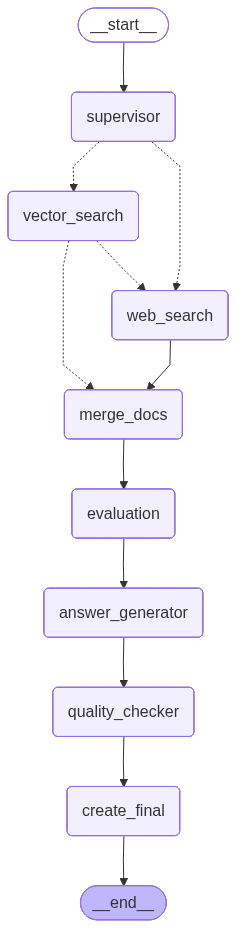

In [39]:
from IPython.display import Image, display

try:
    display(
        Image(
            supervisor_rag_app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 8. Supervisor Agents RAG 시스템 실행 함수


In [40]:
def run_supervisor_rag(question: str, verbose: bool = True):
    """
    Supervisor Agents RAG 시스템을 실행하는 메인 함수
    """
    print("=" * 60)
    print(f"Supervisor Agents RAG 실행")
    print("=" * 60)
    print(f"질문: {question}")
    print("-" * 60)
    
    # 초기 상태 설정
    initial_state = {
        "question": question,
        # "vector_docs": [],
        # "web_docs": [],
        # "all_docs": [],
        # "relevant_docs": [],
        # "sources": [],
        # "quality_score": 0.0,
    }
    
    try:
        # 워크플로우 실행
        result = supervisor_rag_app.invoke(
            initial_state,
            config={"configurable": {"thread_id": "supervisor_rag_thread"}}
        )
        
        if verbose:
            print("\n" + "=" * 60)
            print("실행 결과 요약")
            print("=" * 60)
            print(f"선택된 에이전트: {result.get('selected_agent', 'N/A')}")
            print(f"벡터 검색 문서 수: {len(result.get('vector_docs', []))}")
            print(f"웹 검색 문서 수: {len(result.get('web_docs', []))}")
            print(f"관련 문서 수: {len(result.get('relevant_docs', []))}")
            print(f"품질 점수: {result.get('quality_score', 0.0):.1f}/100")
            print(f"신뢰도: {result.get('confidence', 'N/A')}")
            print(f"출처 수: {len(result.get('sources', []))}")
            print("\n" + "=" * 60)
            print("최종 답변")
            print("=" * 60)
        
        print(result.get("final_answer", "답변을 생성할 수 없습니다."))
        
        return result
        
    except Exception as e:
        error_message = f"Supervisor Agents RAG 실행 중 오류가 발생했습니다: {str(e)}"
        print(error_message)
        import traceback
        traceback.print_exc()
        return {"final_answer": "죄송하지만 시스템 오류로 인해 답변을 제공할 수 없습니다."}

print("Supervisor Agents RAG 실행 함수 구현 완료!")


Supervisor Agents RAG 실행 함수 구현 완료!


## 9. 테스트 예제

다양한 질문으로 Supervisor Agents RAG 시스템을 테스트해봅니다.


### 테스트 1: 벡터 검색만 필요한 질문 (기술 용어)


In [41]:
print("테스트 1: 벡터 검색만 필요한 질문")
print("예상: Supervisor가 'vector' 선택 → Vector 검색 → 평가 → 답변 생성")
print()

result1 = run_supervisor_rag("VectorStore란?")
print("\n" + "="*80 + "\n")


테스트 1: 벡터 검색만 필요한 질문
예상: Supervisor가 'vector' 선택 → Vector 검색 → 평가 → 답변 생성

Supervisor Agents RAG 실행
질문: VectorStore란?
------------------------------------------------------------
Supervisor 결정: vector - VectorStore는 임베딩 벡터를 저장·관리하고 벡터 간 유사도 검색을 수행할 수 있게 해주는 저장소입니다. LLM 파이프라인에서 문서/아이템의 벡터를 인덱스로 구성하고 질의 벡터와의 유사도(예: 코사인 유사도)로 관련 항목을 빠르게 찾는 데 사용됩니다. 예로 FAISS, HNSW 기반 인덱스, Milvus, Pinecone 등의 구현이 있으며, 메타데이터도 함께 보관해 필터링/정렬 등도 가능합니다.
VectorSearchAgent: 'VectorStore란?' 검색 중...
VectorSearchAgent: 5개의 문서를 검색했습니다.
문서 통합: 벡터 5개 + 웹 0개 = 총 5개
EvaluationAgent: 5개 문서의 관련성을 평가 중...
EvaluationAgent: 1개의 관련 문서를 선별했습니다.
AnswerGenerator: 답변 생성 완료
QualityChecker: 품질 점수 87.0/100, 신뢰도: high
최종 답변 생성 완료

실행 결과 요약
선택된 에이전트: vector
벡터 검색 문서 수: 5
웹 검색 문서 수: 0
관련 문서 수: 1
품질 점수: 87.0/100
신뢰도: high
출처 수: 1

최종 답변
VectorStore란 벡터 형식으로 변환된 데이터를 저장하고 관리하는 시스템으로, 벡터 간의 유사도 검색을 빠르게 수행하도록 설계된 저장소입니다. 주로 임베딩(예: 단어, 문장, 이미지의 벡터)을 저장하고, 쿼리 벡터와의 유사도를 기준으로 상위 k개 항목을 반환합니다.

주요 특징
- 벡터 및 메타데이터 저장: 벡터뿐만 아니라 원본 아이템을 식별할 수 있는 ID나

### 테스트 2: 웹 검색이 필요한 질문 (최신 정보)


In [42]:
print("테스트 2: 웹 검색이 필요한 질문")
print("예상: Supervisor가 'web' 선택 → TavilySearch 검색 → 평가 → 답변 생성")
print()

result2 = run_supervisor_rag("최근 AI 기술 동향은?")
print("\n" + "="*80 + "\n")


테스트 2: 웹 검색이 필요한 질문
예상: Supervisor가 'web' 선택 → TavilySearch 검색 → 평가 → 답변 생성

Supervisor Agents RAG 실행
질문: 최근 AI 기술 동향은?
------------------------------------------------------------
Supervisor 결정: web - 최근 AI 기술 동향은 빠르게 변화하고 있으며 최신 연구 발표, 기업 발표, 벤치마크, 정책 이슈 등 실시간 정보가 필요합니다. 벡터 데이터베이스에 저장된 일반적 개념도 참고할 수 있으나, 최신 트렌드(예: 대형 언어 모델의 확장, 멀티모달 모델, 책임성과 규제 동향, 실무 적용 사례 등)는 웹 검색이 더 적합합니다.
WebSearchAgent: '최근 AI 기술 동향은?' 웹 검색 중...
WebSearchAgent: 4개의 웹 문서를 검색했습니다.
문서 통합: 벡터 0개 + 웹 4개 = 총 4개
EvaluationAgent: 4개 문서의 관련성을 평가 중...
EvaluationAgent: 3개의 관련 문서를 선별했습니다.
AnswerGenerator: 답변 생성 완료
QualityChecker: 품질 점수 67.0/100, 신뢰도: medium
최종 답변 생성 완료

실행 결과 요약
선택된 에이전트: web
벡터 검색 문서 수: 0
웹 검색 문서 수: 4
관련 문서 수: 3
품질 점수: 67.0/100
신뢰도: medium
출처 수: 3

최종 답변
다음은 제시된 컨텐츠를 바탕으로 정리한 최근 AI 기술 동향입니다.

- 생성형 AI의 확산과 상용화
  - 텍스트, 코드, 이미지, 3D 콘텐츠까지 자동 생성하는 역량이 빠르게 확대되었고, 데이터와 솔루션 기반의 서비스 출시가 늘고 있습니다. 교육·의료·금융 등 다양한 산업에서 실제 적용 사례가 증가하고 있습니다.

- 대형 모델과 멀티모달 능력의 고도화
  - 대규모 모델의 성능 향상뿐 아니라 텍스트·이미지·코드 등을 연결하는 멀티모달 기능이 강화되고

### 테스트 3: 복합적인 질문 (벡터 + 웹 검색)


In [43]:
print("테스트 3: 복합적인 질문")
print("예상: Supervisor가 'both' 선택 → Vector + TavilySearch 검색 → 평가 → 답변 생성")
print()

result3 = run_supervisor_rag("RAG 기술의 최신 연구 동향과 기본 개념을 설명해주세요.")
print("\n" + "="*80 + "\n")


테스트 3: 복합적인 질문
예상: Supervisor가 'both' 선택 → Vector + TavilySearch 검색 → 평가 → 답변 생성

Supervisor Agents RAG 실행
질문: RAG 기술의 최신 연구 동향과 기본 개념을 설명해주세요.
------------------------------------------------------------
Supervisor 결정: both - RAG의 기본 개념(벡터 기반 검색, 문서 인덱싱/참조, 생성 모델 결합 등)은 벡터 데이터베이스 지식이 필요하고, 최신 연구 동향은 논문, 벤치마크, 시스템 개선 등 실시간 정보 업데이트가 중요하기 때문입니다. 따라서 기본 개념은 vector로, 최신 동향은 web으로 조사하는 것이 적합합니다. 또한 두 가지를 함께 다루는 복합적 요청이 될 수 있습니다.
VectorSearchAgent: 'RAG 기술의 최신 연구 동향과 기본 개념을 설명해주세요.' 검색 중...
VectorSearchAgent: 5개의 문서를 검색했습니다.
WebSearchAgent: 'RAG 기술의 최신 연구 동향과 기본 개념을 설명해주세요.' 웹 검색 중...
WebSearchAgent: 4개의 웹 문서를 검색했습니다.
문서 통합: 벡터 5개 + 웹 4개 = 총 9개
EvaluationAgent: 9개 문서의 관련성을 평가 중...
EvaluationAgent: 1개의 관련 문서를 선별했습니다.
AnswerGenerator: 답변 생성 완료
QualityChecker: 품질 점수 88.0/100, 신뢰도: high
최종 답변 생성 완료

실행 결과 요약
선택된 에이전트: both
벡터 검색 문서 수: 5
웹 검색 문서 수: 4
관련 문서 수: 1
품질 점수: 88.0/100
신뢰도: high
출처 수: 1

최종 답변
다음은 RAG( Retrieval-Augmented Generation) 기술의 기본 개념과 2024년 중반까지의 최신 연구 흐름을 정리한 내용입니다.

1) 기본 개념
-

### 테스트 4: 데이터베이스에 없는 내용


In [44]:
print("테스트 4: 데이터베이스에 없는 내용")
print("예상: 검색 결과 없음 → 관련 문서 없음 → 모른다고 답변")
print()

result4 = run_supervisor_rag("양자컴퓨터의 작동 원리는 무엇인가요?")
print("\n" + "="*80 + "\n")


테스트 4: 데이터베이스에 없는 내용
예상: 검색 결과 없음 → 관련 문서 없음 → 모른다고 답변

Supervisor Agents RAG 실행
질문: 양자컴퓨터의 작동 원리는 무엇인가요?
------------------------------------------------------------
Supervisor 결정: vector - 질문의 내용이 양자컴퓨터의 작동 원리와 같은 기본 개념 설명에 해당하며, 벡터 데이터베이스에서 일반적으로 다루는 정의 및 원리 정보가 필요한 질문이므로.
VectorSearchAgent: '양자컴퓨터의 작동 원리는 무엇인가요?' 검색 중...
VectorSearchAgent: 5개의 문서를 검색했습니다.
문서 통합: 벡터 5개 + 웹 0개 = 총 5개
EvaluationAgent: 5개 문서의 관련성을 평가 중...
EvaluationAgent: 0개의 관련 문서를 선별했습니다.
최종 답변 생성 완료

실행 결과 요약
선택된 에이전트: vector
벡터 검색 문서 수: 5
웹 검색 문서 수: 0
관련 문서 수: 0
품질 점수: 0.0/100
신뢰도: low
출처 수: 0

최종 답변
죄송하지만 해당 질문에 대한 정확한 정보를 제공할 수 없습니다.




## [Langsmith에서 확인하기](https://smith.langchain.com/)


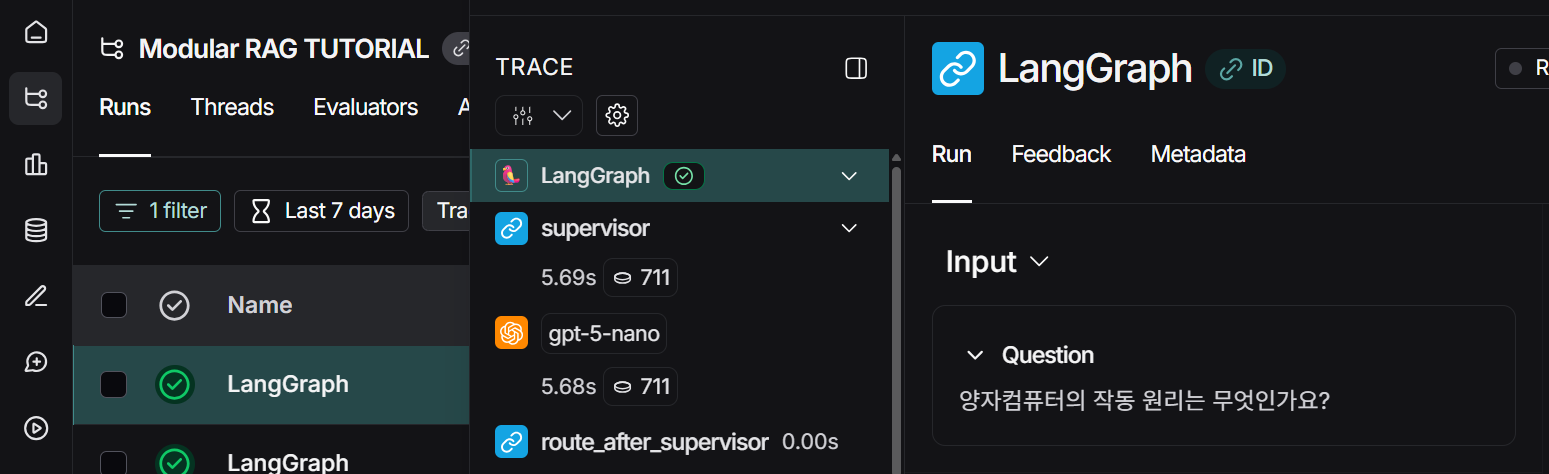